In [1]:
%load_ext autoreload
%autoreload 2

import os, glob, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import container

from astropy.cosmology import Planck18 as cosmo
from astropy import units as u, constants as c

from equipartition import *

from otter import Otter
db = Otter(datadir="private-data")

import syncfit

def get_bounds(chain, ndim=3):
    
    medians, upper, lower = [], [], []
    for i in range(ndim):
        mcmc = np.percentile(chain[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        vals = [mcmc[1],(q[0]+q[1])/2]

        medians.append(mcmc[1])
        upper.append(q[1])
        lower.append(q[0])

    return medians, upper, lower

def get_single_bound(chain1d):
    mcmc = np.percentile(chain1d, [16, 50, 84])
    q = np.diff(mcmc)
    
    return mcmc[1], q[1], q[0]

conf_level = 0.95
f_V = 0.36
f_A = 1

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test


In [2]:
param_uplims = dict(
    name = ['SDSSJ1241', 'SDSSJ1241', 'SDSSJ0938', 'SDSSJ0748', '2020vdq', '2020vdq'],
    mjd = ['60967.0', '57959.0', '57912.0', '57914.0', '59612.0', '60093.5'],
    p_lim = [False, False, False, False, False, False], # these would be upperlimits
    p_lim_type = ["upper"]*6,
    log_F_nu_lim = [False, False, True, True, False, True], # these are lower limits
    log_F_nu_lim_type = ["lower"]*6,
    log_nu_a_lim = [False, False, True, True, False, True], # these are upperlimits on nu_a
    log_nu_a_lim_type = ["upper"]*6
)

In [3]:
labels = ["p", 'log_F_nu', 'log_nu_a']

best_fit_params = dict(
    name = [],
    mjd = [],
    p = [],
    p_up = [],
    p_lo = [],
    p_chain = [],
    log_F_nu = [],
    log_F_nu_up = [],
    log_F_nu_lo = [],
    log_F_nu_chain = [],
    log_nu_a = [],
    log_nu_a_up = [],
    log_nu_a_lo = [],
    log_nu_a_chain = []
)
ii = 0
for jfile in glob.glob(os.path.join(os.getcwd(), "*chains.json")):

    if "SDSSJ0952" in jfile: continue # skip J0952, for now...

    with open(jfile, "r") as j:
        chain_dict = json.load(j)
    
    tname = jfile.split('-')[1].split('/')[1]

    print(tname)

    for k, chain in chain_dict.items():
        medians, uplims, lowlims = get_bounds(np.array(chain))
        print(f"\tMJD = {k}")
        for median, uplim, lowlim, lab, chain_by_key in zip(medians, uplims, lowlims, labels, np.array(chain).T):
            print(f"\t\t${lab} = {median:.2f}^+{uplim:.2f}_-{lowlim:.2f}$")

            print(ii, lab, param_uplims[lab+"_lim"][ii])
            if param_uplims[lab+"_lim"][ii]:
                if param_uplims[lab+"_lim_type"][ii] == "upper":
                    limval = np.quantile(chain_by_key, conf_level)
                else:
                    limval = np.quantile(chain_by_key, 1-conf_level)
                    
                best_fit_params[lab].append(limval)
                best_fit_params[f"{lab}_up"].append(0)
                best_fit_params[f"{lab}_lo"].append(0)
            else:
                best_fit_params[lab].append(median)
                best_fit_params[f"{lab}_up"].append(uplim)
                best_fit_params[f"{lab}_lo"].append(lowlim)
            best_fit_params[f"{lab}_chain"].append(chain_by_key)
        best_fit_params["mjd"].append(k)
        best_fit_params["name"].append(tname)
        ii += 1
    
    print()

res = pd.DataFrame(best_fit_params).merge(pd.DataFrame(param_uplims), on=["name", "mjd"])

res

SDSSJ1241
	MJD = 60967.0
		$p = 3.34^+0.10_-0.10$
0 p False
		$log_F_nu = 0.56^+0.02_-0.02$
0 log_F_nu False
		$log_nu_a = 8.85^+0.02_-0.02$
0 log_nu_a False
	MJD = 57959.0
		$p = 3.72^+0.11_-0.11$
1 p False
		$log_F_nu = 0.93^+0.02_-0.02$
1 log_F_nu False
		$log_nu_a = 9.09^+0.03_-0.03$
1 log_nu_a False

SDSSJ0938
	MJD = 57912.0
		$p = 3.08^+0.10_-0.09$
2 p False
		$log_F_nu = 1.30^+0.48_-0.41$
2 log_F_nu True
		$log_nu_a = 8.36^+0.43_-0.46$
2 log_nu_a True

SDSSJ0748
	MJD = 57914.0
		$p = 2.58^+0.32_-0.30$
3 p False
		$log_F_nu = 0.41^+0.85_-0.76$
3 log_F_nu True
		$log_nu_a = 7.64^+1.02_-1.04$
3 log_nu_a True

2020vdq
	MJD = 59612.0
		$p = 3.60^+0.17_-0.17$
4 p False
		$log_F_nu = 0.57^+0.01_-0.01$
4 log_F_nu False
		$log_nu_a = 9.59^+0.02_-0.02$
4 log_nu_a False
	MJD = 60093.5
		$p = 2.62^+0.03_-0.03$
5 p False
		$log_F_nu = 1.13^+0.60_-0.61$
5 log_F_nu True
		$log_nu_a = 7.80^+0.75_-0.73$
5 log_nu_a True



,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,log_nu_a,log_nu_a_up,log_nu_a_lo,log_nu_a_chain,p_lim,p_lim_type,log_F_nu_lim,log_F_nu_lim_type,log_nu_a_lim,log_nu_a_lim_type
0,SDSSJ1241,60967.0,3.344417,0.103923,0.102835,"[3.570390563530611, 3.414472542313548, 3.41673...",0.557362,0.020544,0.021181,"[0.6061386453855283, 0.5897357587586554, 0.573...",8.849350,0.022466,0.024252,"[8.870014000298832, 8.849734469771562, 8.85189...",False,upper,False,lower,False,upper
1,SDSSJ1241,57959.0,3.715698,0.111777,0.113040,"[3.784832971467307, 3.761122057160362, 3.82533...",0.927823,0.019403,0.019101,"[0.9757941369587491, 0.9538145093086272, 0.922...",9.094379,0.026460,0.030969,"[9.076079949146754, 9.085007636034094, 9.12317...",False,upper,False,lower,False,upper
2,SDSSJ0938,57912.0,3.080320,0.097976,0.089055,"[3.172430747348819, 3.027818050777822, 3.14290...",0.791475,0.000000,0.000000,"[1.7989236309876087, 1.1722949367321158, 0.855...",8.915043,0.000000,0.000000,"[7.9507117836250805, 8.468105708551665, 8.8185...",False,upper,True,lower,True,upper
3,SDSSJ0748,57914.0,2.578675,0.322065,0.300198,"[2.7467678274288003, 2.8965330559289035, 3.508...",-0.556240,0.000000,0.000000,"[1.538386774513024, -0.4591400117233304, -0.47...",9.001400,0.000000,0.000000,"[6.609644913275194, 8.970043759955734, 9.11814...",False,upper,True,lower,True,upper
4,2020vdq,59612.0,3.603838,0.168829,0.170431,"[3.783740311958792, 3.71085336133162, 3.299991...",0.571225,0.012783,0.013738,"[0.5887470398724602, 0.5840821440011682, 0.563...",9.585361,0.015699,0.017233,"[9.609216292555463, 9.586725429883206, 9.55196...",False,upper,False,lower,False,upper
5,2020vdq,60093.5,2.624550,0.033250,0.032338,"[2.713577752829935, 2.571554053874018, 2.60923...",0.305844,0.000000,0.000000,"[1.30690453912328, 0.9816892624230561, 0.47806...",8.818942,0.000000,0.000000,"[7.717645821150934, 7.918054167016847, 8.58790...",False,upper,True,lower,True,upper


In [4]:
# add in other information we need about each object

SDSSJ1241_meta = db.get_meta(names="SDSS_J1241", query_private=True)[0]
SDSSJ0938_meta = db.get_meta(names="SDSS_J0938", query_private=True)[0]
SDSSJ0748_meta = db.get_meta(names="SDSS_J0748", query_private=True)[0]
vdq_meta = db.get_meta(names="2020vdq", query_private=True)[0]


redshift = dict(
    SDSSJ1241 = SDSSJ1241_meta.get_redshift(),
    SDSSJ0938 = SDSSJ0938_meta.get_redshift(),
    SDSSJ0748 = SDSSJ0748_meta.get_redshift()
)
redshift["2020vdq"] = vdq_meta.get_redshift()

disc_date = dict(
    SDSSJ1241 = SDSSJ1241_meta.get_discovery_date().mjd,
    SDSSJ0938 = SDSSJ0938_meta.get_discovery_date().mjd,
    SDSSJ0748 = SDSSJ0748_meta.get_discovery_date().mjd
)
disc_date["2020vdq"] = vdq_meta.get_discovery_date().mjd

lum_dist = dict(
    SDSSJ1241 = None,
    SDSSJ0938 = None,
    SDSSJ0748 = None
)
lum_dist["2020vdq"] = None

# I get all of these velocity dispersions by querying SDSS for the coordinates from the name
vel_disp = dict(
    SDSSJ0748 = 79.33013,
    SDSSJ0938 = 126.8426,
    SDSSJ1241 = 85.12043
)

vel_disp_err = dict(
    SDSSJ0748 = 8.36008,
    SDSSJ0938 = 9.147189,
    SDSSJ1241 = 11.9128
)

for name, z in redshift.items():
    lum_dist[name] = cosmo.luminosity_distance(z).to("cm").value

res['z'] = res.name.map(redshift).astype(float)
res["lum_dist"] = res.name.map(lum_dist).astype(float)
res["disc_date"] = res.name.map(disc_date).astype(float)

res["vel_disp"] = res.name.map(vel_disp).astype(float)
res["vel_disp_err"] = res.name.map(vel_disp_err).astype(float)

# compute the black hole mass using M-sigma
# Using this relation: https://iopscience.iop.org/article/10.1088/0004-637X/698/1/198
def Msigma(sigma_km_s):
    alpha = 8.12
    beta = 4.24
    return alpha + beta*np.log10(sigma_km_s/200)

def Msigma_err(sigma, sigma_err):
    alpha_err = 0.08
    beta_err = 0.41
    alpha = 8.12
    beta = 4.24
    return np.sqrt(alpha_err**2 + (beta*sigma_err/(sigma*np.log(10)))**2)

res["log_M_bh"] = Msigma(res.vel_disp)
res["log_M_bh_err"] = Msigma_err(res.vel_disp, res.vel_disp_err)
res["M_bh"] = 10**res.log_M_bh
res["M_bh_err"] = res.M_bh * (res.log_M_bh_err * np.log(10))

# then calculate the swarschild radius
def R_s(M_bh):
    r_s = 2*c.G*M_bh/c.c**2
    return r_s.cgs.value

res["R_s"] = R_s(res.M_bh.to_numpy()*c.M_sun)
res["R_s_err"] = R_s(res.M_bh_err.to_numpy()*c.M_sun)

res["dt"] = res.mjd.astype(float) - res.disc_date

# determine if each F_nu, p, and log_nu should be upperlimits
def is_upperlimit(df, key, model=syncfit.models.B5(), uplim_factor=3):
    
    key_prior = model.prior[key]
    
    median = df[key]
    up = df[f"{key}_up"]
    lo = df[f"{key}_lo"]
        
    return median+(up*uplim_factor) > key_prior[1]
    
    
res["log_F_nu_uplim"] = is_upperlimit(res, "log_F_nu")
res["log_nu_a_uplim"] = is_upperlimit(res, "log_nu_a")
res["p_uplim"] = is_upperlimit(res, "p")

res

Names have the same score! Just using the existing default_name


,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,log_M_bh,log_M_bh_err,M_bh,M_bh_err,R_s,R_s_err,dt,log_F_nu_uplim,log_nu_a_uplim,p_uplim
0,SDSSJ1241,60967.0,3.344417,0.103923,0.102835,"[3.570390563530611, 3.414472542313548, 3.41673...",0.557362,0.020544,0.021181,"[0.6061386453855283, 0.5897357587586554, 0.573...",...,6.546976,0.269841,3.523515e+06,2.189272e+06,1.040582e+12,6.465467e+11,7905.00000,False,False,False
1,SDSSJ1241,57959.0,3.715698,0.111777,0.113040,"[3.784832971467307, 3.761122057160362, 3.82533...",0.927823,0.019403,0.019101,"[0.9757941369587491, 0.9538145093086272, 0.922...",...,6.546976,0.269841,3.523515e+06,2.189272e+06,1.040582e+12,6.465467e+11,4897.00000,False,False,True
2,SDSSJ0938,57912.0,3.080320,0.097976,0.089055,"[3.172430747348819, 3.027818050777822, 3.14290...",0.791475,0.000000,0.000000,"[1.7989236309876087, 1.1722949367321158, 0.855...",...,7.281477,0.155028,1.911952e+07,6.825016e+06,5.646472e+12,2.015598e+12,3820.00000,False,False,False
3,SDSSJ0748,57914.0,2.578675,0.322065,0.300198,"[2.7467678274288003, 2.8965330559289035, 3.508...",-0.556240,0.000000,0.000000,"[1.538386774513024, -0.4591400117233304, -0.47...",...,6.417251,0.209897,2.613669e+06,1.263204e+06,7.718819e+11,3.730557e+11,4979.00000,False,False,False
4,2020vdq,59612.0,3.603838,0.168829,0.170431,"[3.783740311958792, 3.71085336133162, 3.299991...",0.571225,0.012783,0.013738,"[0.5887470398724602, 0.5840821440011682, 0.563...",...,NaN,NaN,NaN,NaN,NaN,NaN,485.50838,False,False,True
5,2020vdq,60093.5,2.624550,0.033250,0.032338,"[2.713577752829935, 2.571554053874018, 2.60923...",0.305844,0.000000,0.000000,"[1.30690453912328, 0.9816892624230561, 0.47806...",...,NaN,NaN,NaN,NaN,NaN,NaN,967.00838,False,False,False


In [5]:
equipartition_results = dict( 
    name = [],
    mjd = [],
    
    n_e_chain = [],
    n_e = [],
    n_e_up = [],
    n_e_lo = [],
    n_e_lim = [False, False, True, True, False, True],
    n_e_lim_type = 'upper',
    
    Req_chain = [],
    Req = [],
    Req_up = [],
    Req_lo = [],
    Req_lim = [False, False, True, True, False, True],
    Req_lim_type = 'lower',
    
    Eeq_chain = [],
    Eeq = [],
    Eeq_up = [],
    Eeq_lo = [],
    Eeq_lim = [False, False, True, True, False, True],
    Eeq_lim_type = 'lower',
)

for ii, (_, row) in enumerate(res.iterrows()):
    
    equipartition_results["name"].append(row['name'])
    equipartition_results["mjd"].append(row.mjd)
    
    r_eq_val = Req(
        p = row.p_chain, 
        F_p_mJy = 10**row.log_F_nu_chain, 
        nu_p = 10**row.log_nu_a_chain, 
        z = row.z, 
        d_L = row.lum_dist,
        f_V = f_V,
        f_A = f_A
    )
        
    equipartition_results["Req_chain"].append(r_eq_val)
    req, req_up, req_lo = get_single_bound(r_eq_val)

    if equipartition_results["Req_lim"][ii]:
        equipartition_results["Req"].append(np.quantile(r_eq_val, 1-conf_level))
        equipartition_results["Req_up"].append(0)
        equipartition_results["Req_lo"].append(0)
    else:
        equipartition_results["Req"].append(np.median(req))
        equipartition_results["Req_up"].append(req_up)
        equipartition_results["Req_lo"].append(req_lo)
    
    
    e_eq_val = Eeq(
        p = row.p_chain, 
        F_p_mJy = 10**row.log_F_nu_chain, 
        nu_p = 10**row.log_nu_a_chain, 
        z = row.z, 
        d_L = row.lum_dist,
        f_V = f_V,
        f_A = f_A
    )

    equipartition_results["Eeq_chain"].append(e_eq_val)
    eeq, eeq_up, eeq_lo = get_single_bound(e_eq_val)
    if equipartition_results["Eeq_lim"][ii]:
        equipartition_results["Eeq"].append(np.quantile(e_eq_val, 1-conf_level))
        equipartition_results["Eeq_up"].append(0)
        equipartition_results["Eeq_lo"].append(0)
    else:    
        equipartition_results["Eeq"].append(eeq)
        equipartition_results["Eeq_up"].append(eeq_up)
        equipartition_results["Eeq_lo"].append(eeq_lo)
    
    n_e_val = n_e(
        p = row.p_chain,
        F_p_mJy = 10**row.log_F_nu_chain,
        d_L = row.lum_dist,
        nu_p = 10**row.log_nu_a_chain,
        z = row.z,
        R_17 = r_eq_val/1e17,
        f_A = f_A
    )
    
    equipartition_results["n_e_chain"].append(n_e_val)
    ne, ne_up, ne_lo = get_single_bound(n_e_val)

    if equipartition_results["n_e_lim"][ii]:
        equipartition_results["n_e"].append(np.quantile(n_e_val, conf_level))
        equipartition_results["n_e_up"].append(0)
        equipartition_results["n_e_lo"].append(0)
    else:    
        equipartition_results["n_e"].append(ne)
        equipartition_results["n_e_up"].append(ne_up)
        equipartition_results["n_e_lo"].append(ne_lo)

results_df = res.merge(pd.DataFrame(equipartition_results), on=["name", "mjd"])

results_df

,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,Req_up,Req_lo,Req_lim,Req_lim_type,Eeq_chain,Eeq,Eeq_up,Eeq_lo,Eeq_lim,Eeq_lim_type
0,SDSSJ1241,60967.0,3.344417,0.103923,0.102835,"[3.570390563530611, 3.414472542313548, 3.41673...",0.557362,0.020544,0.021181,"[0.6061386453855283, 0.5897357587586554, 0.573...",...,2.455924e+16,2.341268e+16,False,lower,"[3.8263337607225385e+50, 2.9322828660897612e+5...",2.373223e+50,5.003704e+49,4.137755e+49,False,lower
1,SDSSJ1241,57959.0,3.715698,0.111777,0.113040,"[3.784832971467307, 3.761122057160362, 3.82533...",0.927823,0.019403,0.019101,"[0.9757941369587491, 0.9538145093086272, 0.922...",...,3.372813e+16,2.723855e+16,False,lower,"[9.680402138590008e+50, 8.570335531793921e+50,...",7.262442e+50,1.285248e+50,1.114724e+50,False,lower
2,SDSSJ0938,57912.0,3.080320,0.097976,0.089055,"[3.172430747348819, 3.027818050777822, 3.14290...",0.791475,0.000000,0.000000,"[1.7989236309876087, 1.1722949367321158, 0.855...",...,0.000000e+00,0.000000e+00,True,lower,"[3.700070522381106e+53, 1.4685171114003402e+52...",2.529247e+51,0.000000e+00,0.000000e+00,True,lower
3,SDSSJ0748,57914.0,2.578675,0.322065,0.300198,"[2.7467678274288003, 2.8965330559289035, 3.508...",-0.556240,0.000000,0.000000,"[1.538386774513024, -0.4591400117233304, -0.47...",...,0.000000e+00,0.000000e+00,True,lower,"[5.081052133290154e+53, 1.1686862823988807e+49...",5.215960e+48,0.000000e+00,0.000000e+00,True,lower
4,2020vdq,59612.0,3.603838,0.168829,0.170431,"[3.783740311958792, 3.71085336133162, 3.299991...",0.571225,0.012783,0.013738,"[0.5887470398724602, 0.5840821440011682, 0.563...",...,2.310252e+15,2.310972e+15,False,lower,"[1.1241721276411515e+50, 1.0375862508541863e+5...",8.409678e+49,2.690011e+49,2.114514e+49,False,lower
5,2020vdq,60093.5,2.624550,0.033250,0.032338,"[2.713577752829935, 2.571554053874018, 2.60923...",0.305844,0.000000,0.000000,"[1.30690453912328, 0.9816892624230561, 0.47806...",...,0.000000e+00,0.000000e+00,True,lower,"[9.254301037410566e+51, 1.7665586615871678e+51...",3.870644e+49,0.000000e+00,0.000000e+00,True,lower


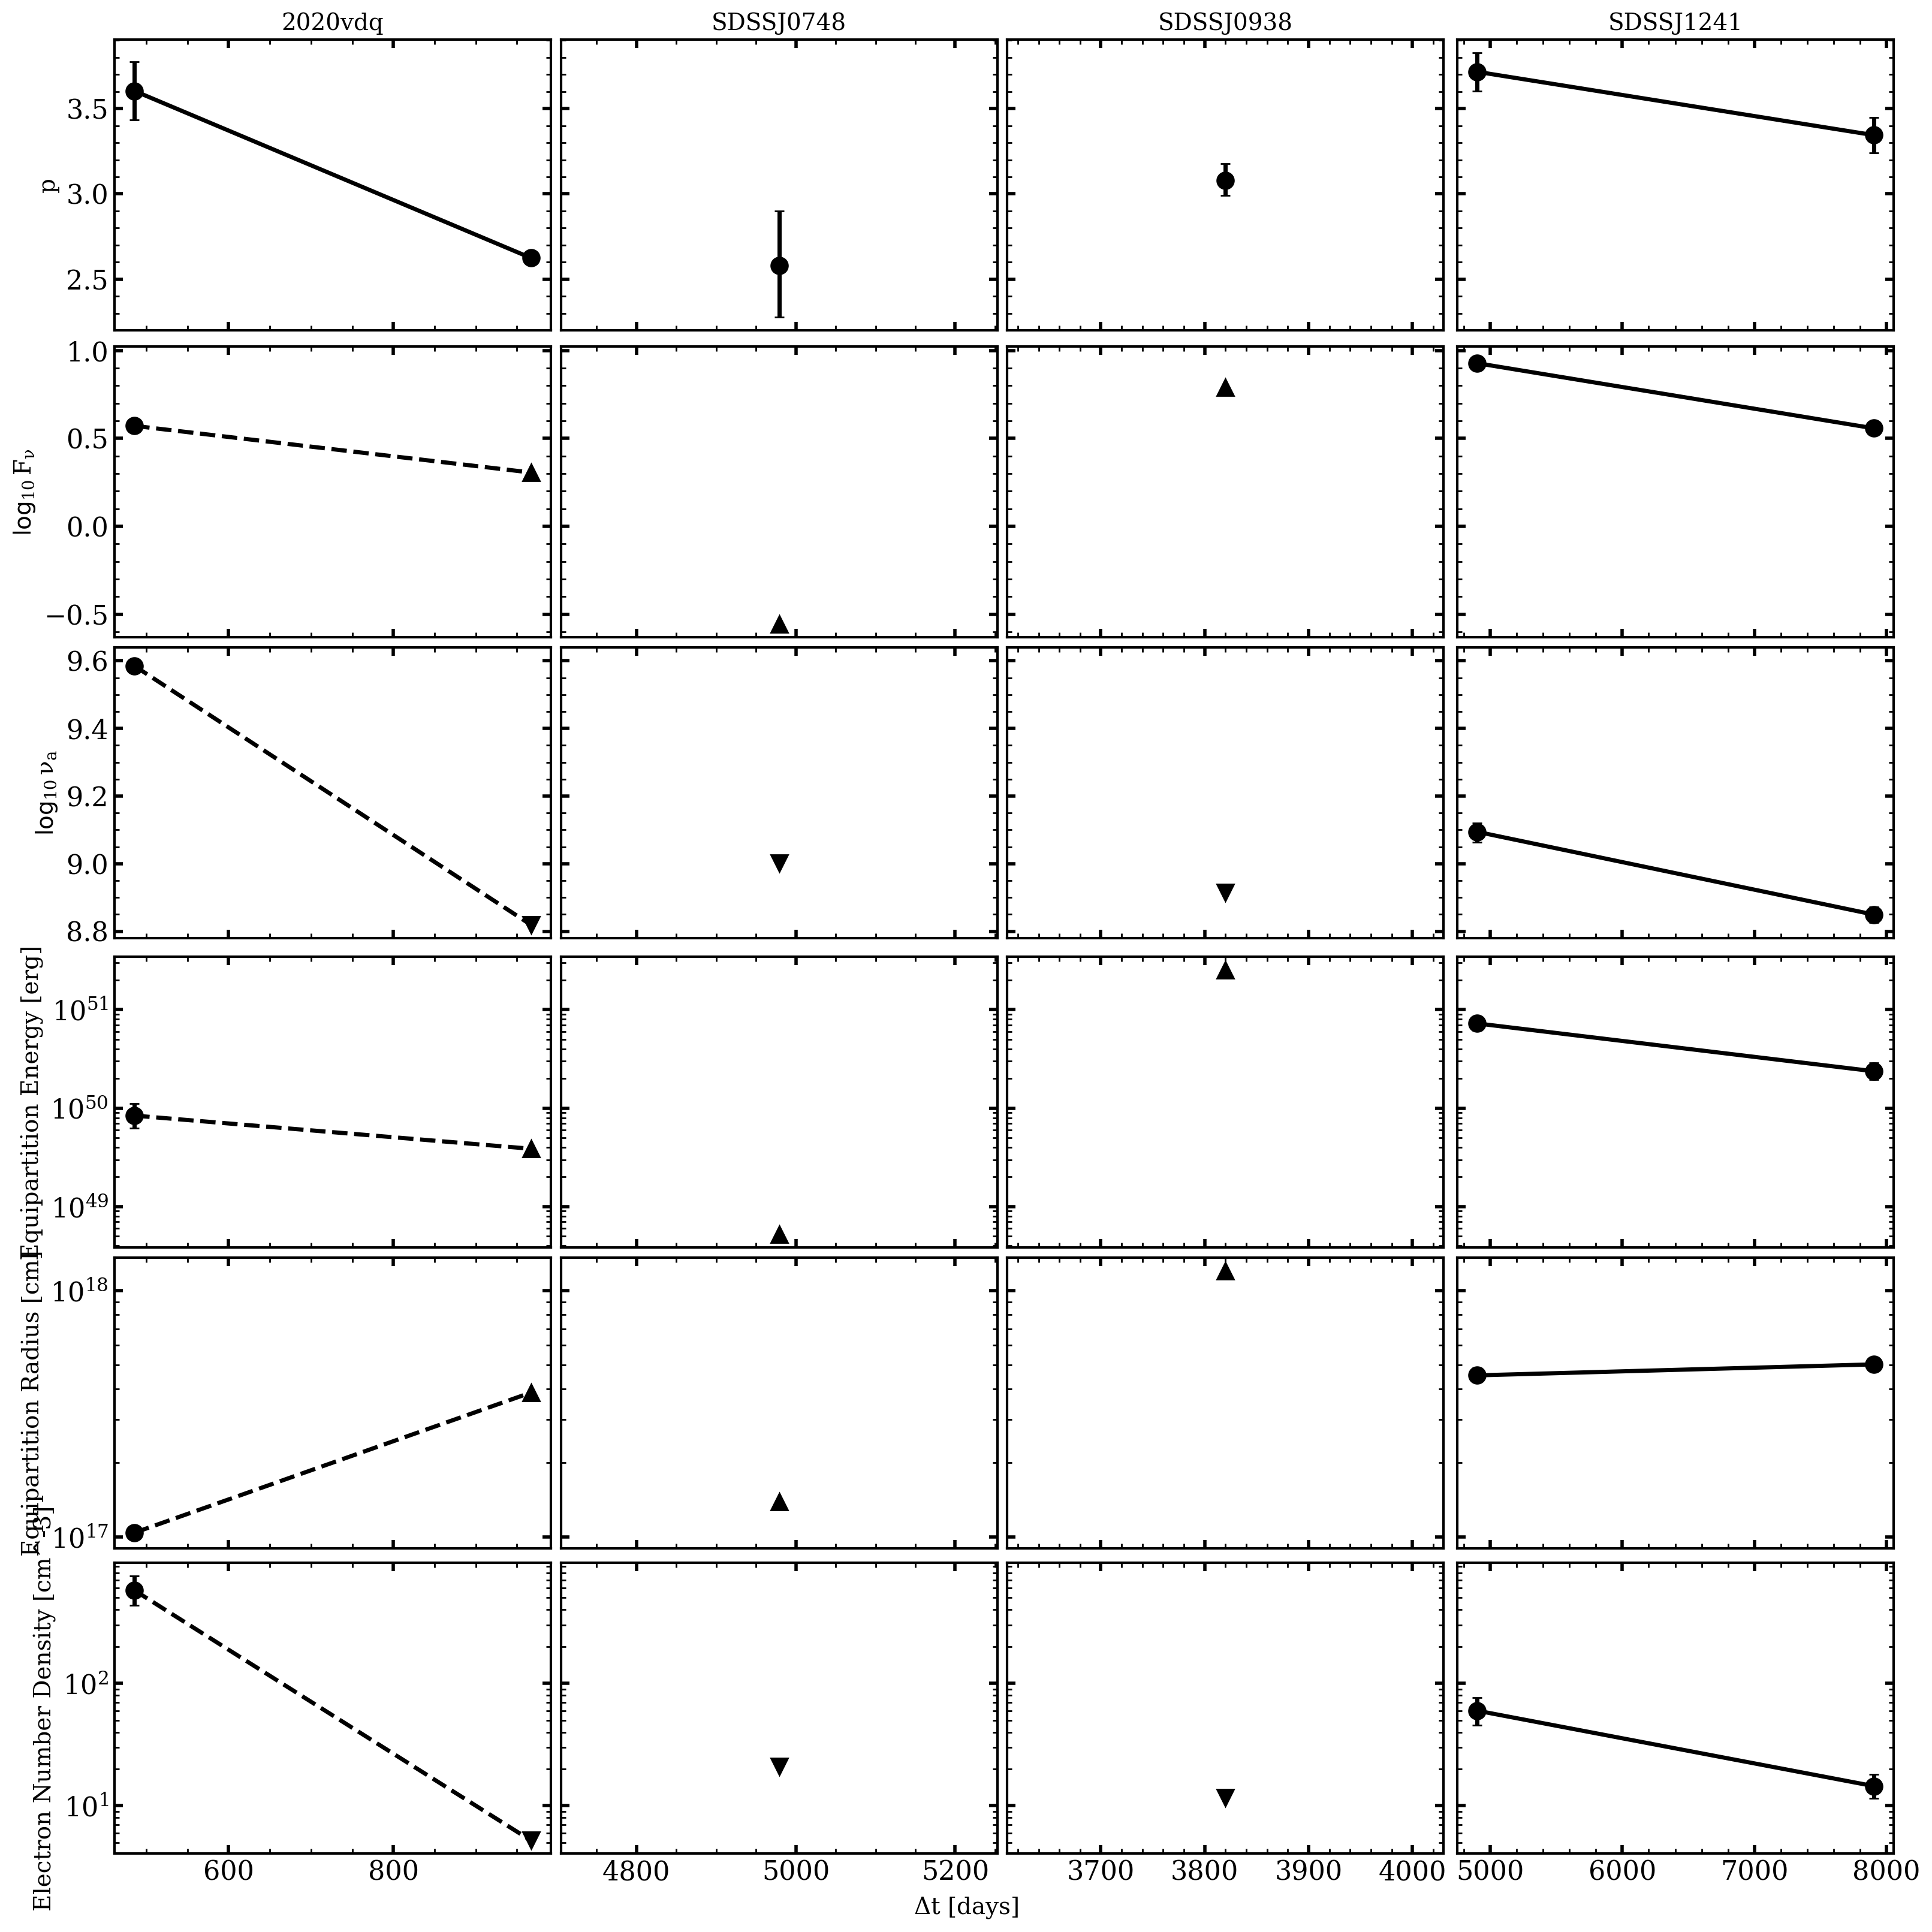

In [6]:
keys = {
    "p" : "p",
    "log_F_nu": r"$\log_{10} F_{\nu}$",
    "log_nu_a": r"$\log_{10} \nu_a$",
    "Eeq" : "Equipartition Energy [erg]",
    "Req" : "Equipartition Radius [cm]",
    "n_e" : "Electron Number Density [cm^-3]"
}

ranges = {
    "Eeq" : (1e48, 1e52),
    "Req" : (1e17, 1e20),
    "p": (2,4),
    "log_F_nu": (0,5),
    "log_nu_a": (6,10),
}

fig, axs = plt.subplots(len(keys),4, sharex="col", sharey="row", figsize=(16,16), layout="constrained")

xvar = "dt"

priors = syncfit.models.B5().prior
ranges = priors | ranges # this will default to the priors but replace them with anything in ranges

label_fs = 14
ms = 10

for idx, (ax1d, (key, label)) in enumerate(zip(axs, keys.items())):
    ax1d[0].set_ylabel(label, fontsize=label_fs)
    for jj, (ax, (name, grp)) in enumerate(zip(ax1d, results_df.groupby("name"))):
        cplot = 'k'

        not_uplim = grp[~grp[key+"_lim"]]
        ax.errorbar(
            not_uplim[xvar], 
            not_uplim[key], 
            yerr=(not_uplim[key+"_lo"], not_uplim[key+"_up"]), 
            marker='o', 
            linestyle='none', 
            color=cplot,
            capsize=3,
            markersize=ms
        )

        uplims = grp[grp[key+"_lim"]]
        if len(uplims) > 0:
            lim_type = uplims[key+"_lim_type"].iloc[0]
            symb = 'v' if lim_type == "upper" else '^'
            
            ax.plot(
                grp.loc[uplims.index, xvar],
                grp.loc[uplims.index, key],
                marker=symb,
                linestyle='none',
                color=cplot,
                markersize=ms
            )

        if not idx:
            ax.set_title(f"{name}", fontsize=label_fs)
        
        grp = grp.reset_index()
        if len(grp) <= 1: continue
        for ii,row in grp.iterrows():

            if ii == 0:
                # just check if the next one is an upperlimit
                hasuplim = row[key+"_lim"] or grp.iloc[ii+1][key+"_lim"]
            elif ii == len(grp)-1:
                hasuplim = row[key+"_lim"] or grp.iloc[ii-1][key+"_lim"]
            else:
                hasuplim = row[key+"_lim"] or grp.iloc[ii-1][key+"_lim"] or grp.iloc[ii+1][key+"_lim"]

            linestyle='-'
            if hasuplim:
                linestyle='--'

            ax.plot(
                grp.iloc[ii-1:ii+1][xvar],
                grp.iloc[ii-1:ii+1][key],
                marker='none',
                linestyle=linestyle,
                color=cplot
            )

        # ax.set_ylim(*ranges[key])
        # ax.set_xscale("log")

axs[-1][0].set_yscale("log")
axs[-2][0].set_yscale("log")
axs[-3][0].set_yscale("log")

fig.supxlabel(r"$\Delta$t [days]", fontsize=label_fs)

fig.savefig("equipartition-results-bootstrap.png", bbox_inches="tight")

# Plot Equipartition Results against literature

In [7]:
def draw_limit_arrow(df, ax, direction, ratio=3, xkey='Req', ykey="n_e", norm_Req=True, **kwargs):
        
    if xkey == "Req" and norm_Req:
        center_xs = df.Req/df.R_s
    else:
        center_xs = df[xkey]
    
    print(len(df))
    
    center_ys = df[ykey]
        
    if direction == "left":
        u = -1*np.ones(len(df))
        v = np.zeros(len(df))
        
    elif direction == "right":
        u = np.ones(len(df))
        v = np.zeros(len(df))
    
    elif direction == "up":
        u = np.zeros(len(df))
        v = np.ones(len(df))
        
    elif direction == "down":
        u = np.zeros(len(df))
        v = -1*np.ones(len(df))
    
    else:
        raise Exception()
    
    ax.quiver(
        center_xs,
        center_ys,
        u,
        v,
        width=0.002,
        headwidth=5,
        scale_units="inches",
        **kwargs
    )

In [8]:
lit = pd.read_csv("lit_sed_params.csv", comment="#")

# gamma(F_p_mJy, nu_p, z, d_L, t_d, eta=1, f_V=1, f_A=1)
lit["gamma"] = Gamma(
    F_p_mJy = lit.Fp_mJy, 
    nu_p = lit.nu_a*1e9, 
    z = lit.z, 
    d_L = cosmo.luminosity_distance(lit.z).to("cm").value, 
    t_d = lit.t
)

lit.gamma = lit.gamma.apply(lambda v : v if v > 1 else 1)

# Req(p, F_p_mJy, nu_p, z, d_L, epsilon_e=0.1, gamma=1, f_V=1, f_A=1):
lit["Req"] = [Req(
    p = r.p, 
    F_p_mJy = r.Fp_mJy, 
    nu_p = r.nu_a*1e9, 
    z = r.z, 
    d_L = cosmo.luminosity_distance(r.z).to("cm").value,
    gamma = r.gamma,
    epsilon_e = r.epsilon_e,
    epsilon_B = r.epsilon_B,
    nu_m = r.nu_m if r.nu_m > 0 else None
) for _, r in lit.iterrows()]

# n_e(F_p_mJy, d_L, nu_p, z, R_17, f_A=1, eta=1, emitting_region_width_fraction=0.1)
lit["n_e"] = n_e(
    p = lit.p,
    F_p_mJy = lit.Fp_mJy, 
    d_L = cosmo.luminosity_distance(lit.z).to("cm").value, 
    nu_p = lit.nu_a*1e9, 
    z = lit.z,
    R_17 = lit.Req/1e17,
    gamma = lit.gamma
)

# Eeq(p, F_p_mJy, nu_p, z, d_L, epsilon_e=0.1, epsilon_B=None, gamma=1, f_V=0.36, f_A=1, nu_m=None)
lit["Eeq"] = [Eeq(
    p = r.p, 
    F_p_mJy = r.Fp_mJy, 
    nu_p = r.nu_a*1e9, 
    z = r.z, 
    d_L = cosmo.luminosity_distance(r.z).to("cm").value,
    gamma = r.gamma,
    epsilon_e = r.epsilon_e,
    epsilon_B = r.epsilon_B,
) for _, r in lit.iterrows()]

# beta
lit["beta"] = beta(
    t = (lit.t.values*u.day).to(u.s),
    z = lit.z,
    R = lit.Req
)

In [9]:
# Add the ASASSN-19bt profile from Collin
with open("ASASSN19bt_fit_params.json", "r") as f:
    asassn19bt = pd.DataFrame([eval(line) for line in f.readlines()])

asassn19bt_merge = pd.DataFrame(
    dict(
        Name = "ASASSN-19bt",
        t = asassn19bt.t,
        Req = asassn19bt.R_t,
        n_e = asassn19bt.Next_t,
        Eeq = asassn19bt.E_t
    )
)


lit = pd.concat([lit, asassn19bt_merge])
lit = lit[lit.Name != "CNSSJ0019+00"]

In [10]:
lit

,Name,t,p,epsilon_e,epsilon_B,nu_a,nu_a_error,nu_m,nu_m_error,Fp_mJy,Fp_mJy_error,dist_Mpc,z,gamma,Req,n_e,Eeq,beta
4,ASASSN-14li,128,3.0,0.1,0.1,16.80,0.00,-99.99,-99.99,1.91,0.00,90.0,0.0206,1.0,7.920084e+15,5190.209138,4.653733e+47,0.023800
5,ASASSN-14li,143,3.0,0.1,0.1,8.20,0.10,-99.99,-99.99,1.76,0.01,90.0,0.0206,1.0,1.560988e+16,1257.975090,8.635711e+47,0.041238
6,ASASSN-14li,207,3.0,0.1,0.1,4.37,0.20,-99.99,-99.99,1.23,0.03,90.0,0.0206,1.0,2.471856e+16,385.271333,1.050179e+48,0.044937
7,ASASSN-14li,246,3.0,0.1,0.1,4.00,0.06,-99.99,-99.99,1.14,0.01,90.0,0.0206,1.0,2.605031e+16,327.998024,1.046495e+48,0.040054
8,ASASSN-14li,304,3.0,0.1,0.1,2.55,0.06,-99.99,-99.99,0.94,0.02,90.0,0.0206,1.0,3.729485e+16,138.825379,1.299699e+48,0.046110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,ASASSN-19bt,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.112582e+16,183.128343,5.200673e+47,NaN
3,ASASSN-19bt,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.348447e+16,58.589324,1.450233e+48,NaN
4,ASASSN-19bt,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.461083e+16,101.537162,8.229193e+48,NaN
5,ASASSN-19bt,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.275907e+17,24.148662,1.498202e+49,NaN


In [11]:
# update the Sw J1644+57 equipartition energies directly from Eftekhari+2018

j1644_energy = np.loadtxt(io.StringIO("""
50.27
50.48
50.61
50.63
50.93
51.08
51.23
51.40
51.43
51.50
51.55
51.53
51.57
51.54
51.51
51.49
51.44
51.59
51.41
51.48
51.40
51.31
51.49
"""))

j1644_t = np.loadtxt(io.StringIO("""
5
10
15
22
36
51
68
97
126
161
197
216
244
301
390
457
582
645
791
1030
1100
1362
1894
"""))

# lit[lit.Name == "SwJ1644+57"]
updated_from_lit = pd.DataFrame({"updated_eeq":10**j1644_energy, "updated_t":j1644_t})

matching_indices = lit[(lit.Name == "SwJ1644+57")*(lit.t.isin(updated_from_lit.updated_t))].index
lit.loc[matching_indices, 'Eeq'] = lit.loc[matching_indices, 't'].map(
    updated_from_lit.set_index('updated_t')['updated_eeq']
)

lit[lit.Name == "SwJ1644+57"]

,Name,t,p,epsilon_e,epsilon_B,nu_a,nu_a_error,nu_m,nu_m_error,Fp_mJy,Fp_mJy_error,dist_Mpc,z,gamma,Req,n_e,Eeq,beta
29,SwJ1644+57,5,2.5,0.1,0.001,51.286138,20.665872,398.107171,0.000000,19.751995,21.215,1900.0,0.354,2.184140,6.993878e+16,131.874570,1.862087e+50,0.879691
30,SwJ1644+57,10,2.5,0.1,0.001,12.882496,2.373043,213.796209,123.070991,11.106425,3.090,1900.0,0.354,2.935658,2.482063e+17,0.812266,3.019952e+50,0.928442
31,SwJ1644+57,15,2.5,0.1,0.001,9.549926,1.869109,141.253754,60.171026,9.979705,2.375,1900.0,0.354,2.627676,3.000032e+17,1.133627,4.073803e+50,0.912701
32,SwJ1644+57,22,2.5,0.1,0.001,11.220185,0.387531,57.543994,11.262495,8.519851,0.675,1900.0,0.354,1.695412,1.888701e+17,69.847091,4.265795e+50,0.817775
33,SwJ1644+57,36,2.5,0.1,0.001,6.760830,0.544859,70.794578,0.000000,10.448713,1.030,1900.0,0.354,1.832964,3.588550e+17,12.047960,8.511380e+50,0.838989
34,SwJ1644+57,51,2.5,0.1,0.001,8.128305,1.029386,69.183097,0.000000,12.329237,2.095,1900.0,0.354,1.328303,2.787666e+17,344.811744,1.202264e+51,0.740751
35,SwJ1644+57,68,2.5,0.1,0.001,8.912509,0.307827,51.286138,0.000000,15.229410,1.210,1900.0,0.354,1.089050,2.804344e+17,3145.013241,1.698244e+51,0.683122
36,SwJ1644+57,97,2.5,0.1,0.001,7.943282,0.548703,30.902954,3.913618,17.491479,2.755,1900.0,0.354,1.000000,3.885095e+17,2655.683317,2.511886e+51,0.676762
37,SwJ1644+57,126,2.5,0.1,0.001,8.128305,0.467903,21.379621,1.476852,16.143394,2.410,1900.0,0.354,1.000000,3.655555e+17,2830.848705,2.691535e+51,0.602636
38,SwJ1644+57,161,2.5,0.1,0.001,7.244360,0.667230,12.882496,1.779783,15.582227,7.990,1900.0,0.354,1.000000,4.033644e+17,2266.371894,3.162278e+51,0.567034


[(nan, nan), (0, 0)]
4    576.232009
5      5.206458
Name: n_e, dtype: float64
1
1
3    20.846222
Name: n_e, dtype: float64
1
1
2    11.57825
Name: n_e, dtype: float64
1
1
[(271821.7209726901, 272493.00401804654), (300693.7550669303, 300778.2081204725)]
1    59.887493
0    14.493115
Name: n_e, dtype: float64


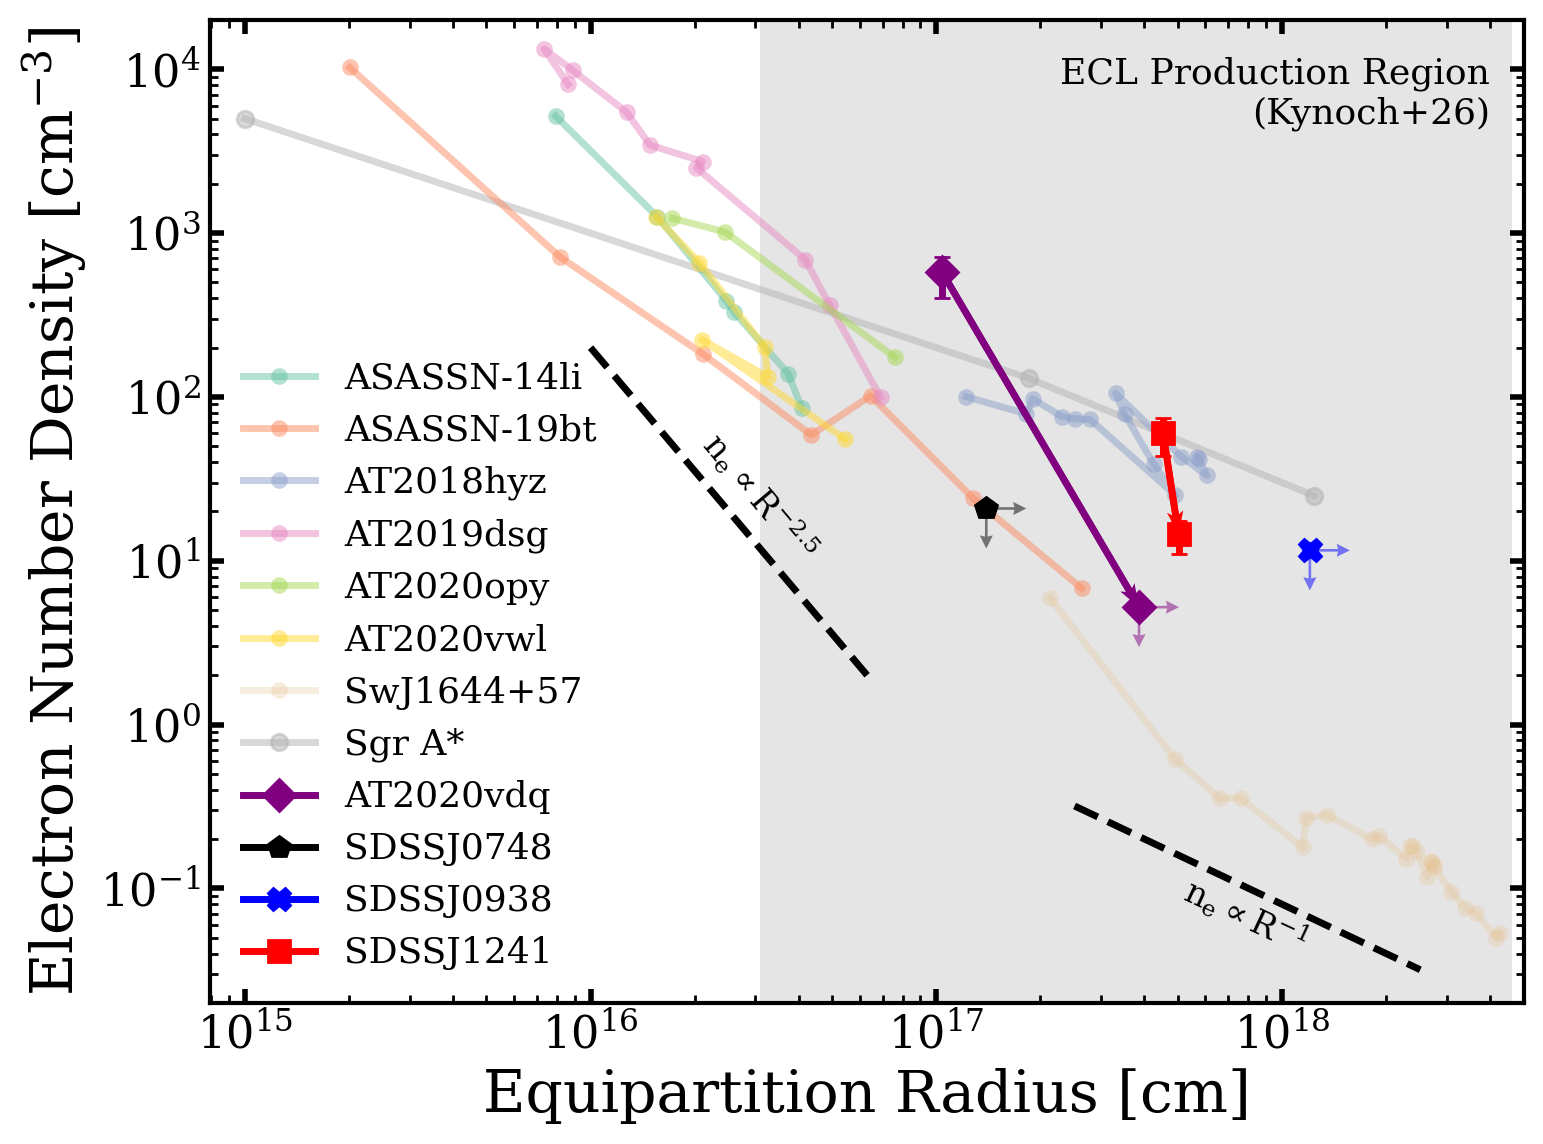

In [12]:
lit_density_profiles = pd.read_csv("density_profile_litTDEs.csv", index_col=0)
bh_masses = pd.read_csv("bh_masses_host.txt", sep="\t")
bh_masses["R_s"] = R_s((10**bh_masses.bhmass.to_numpy())*c.M_sun)

SCALE = 5

ecle_zorder = 100
tde_zorder = 50
bh_zorder = 25
fill_zorder = 1

symbs = ["s", "X", "p", "D"]
symbs_idx = 0

name_map = {
    "SwJ1644+57" : "Sw J1644+57",
    #"CNSSJ0019+00" : "CNSS J0019+00"
}

# now plot the n_e values on a n_e vs. radius

fig, ax = plt.subplots(figsize=(8,6))

color_dict = {
    "SDSSJ1241" : ("red", "s"),
    "SDSSJ0938" : ("blue", "X"),
    "SDSSJ0748" : ("black", "p"),
    "2020vdq":("purple", "D")
}

names_to_plot = {"SDSSJ1241", "SDSSJ0748", "SDSSJ0938", "2020vdq"}


ax.set_xscale("log")
ax.set_yscale("log")

results_df["Req_Rs_err_lo"] = results_df.Req/results_df.R_s * np.sqrt((results_df.R_s_err/results_df.R_s)**2 + (results_df.Req_lo/results_df.Req)**2)
results_df["Req_Rs_err_up"] = results_df.Req/results_df.R_s * np.sqrt((results_df.R_s_err/results_df.R_s)**2 + (results_df.Req_up/results_df.Req)**2)

# add the ECLE density profiles
for name, grp in results_df.groupby("name"):
    
    if name not in names_to_plot: continue


    label_name = name
    if label_name == "2020vdq":
        label_name = "AT"+label_name
    
    grp = grp.sort_values("mjd")

    color, symb = color_dict[name]
    
    yerr = [(0,0)]*len(grp)
    if len(grp[~grp.n_e_lim]) > 0:
        yerr = [(r.n_e_up, r.n_e_lo) if not r.n_e_lim else (0, 0) for _,r in grp.iterrows()]
        
    xerr = [(0,0)]*len(grp)
    if len(grp[~grp.Req_lim]) > 0:
        xerr = [
            (
                r.Req_Rs_err_lo, 
                r.Req_Rs_err_up
            ) if not r.Req_lim 
            else (0, 0) 
            for _,r in grp.iterrows()
        ]
        print(xerr)
    
    ax.errorbar(
        # grp.Req/grp.R_s,
        grp.Req.values,
        grp.n_e,
        yerr = list(zip(*yerr)),
        xerr = list(zip(*xerr)),
        color = color,
        label = label_name,
        linestyle = "-",
        marker = symb,
        capsize = 3,
        zorder = ecle_zorder,
        ms=8
    )

    if len(grp) > 1:
        # x = (grp.Req/grp.R_s).values
        x = grp.Req.values
        y = grp.n_e.values
        ax.quiver(x[:-1], y[:-1], x[1:]-x[:-1], y[1:]-y[:-1], scale_units='xy', angles='xy', scale=1, 
                  width=0.005, headlength=3.5, headaxislength=3, headwidth=2.5, zorder=100, color=color)
    
    print(grp.n_e)
    
    symbs_idx += 1
    
    r_lim = grp[grp.Req_lim]
    if not len(r_lim): continue
    direction = "left" if r_lim.Req_lim_type.iloc[0] == "upper" else "right"
    draw_limit_arrow(r_lim, ax, direction, color=color, alpha=0.5, scale=SCALE, zorder=ecle_zorder, norm_Req=False)
    
    ne_lim = grp[grp.n_e_lim]
    direction = "down" if r_lim.n_e_lim_type.iloc[0] == "upper" else "up"
    draw_limit_arrow(ne_lim, ax, direction, color=color, alpha=0.5, scale=SCALE, zorder=ecle_zorder, norm_Req=False)

# add literature Density profiles
color_idx = 0
for name, grp in lit.groupby("Name"):

    grp = grp.sort_values("t")
    
    if name in name_map:
        # then just plot the literature ones 
        # some of these are more complex to calculate than others so we will defer to the
        # literature values
        lit_densities = lit_density_profiles[lit_density_profiles.name == name_map[name]]
        
        ax.plot(
            lit_densities["R"], # ["R/Rs"]
            lit_densities.n,
            marker = "o", #symbs[symbs_idx],
            linestyle = '-',
            alpha=0.3,
            label=name,
            zorder = tde_zorder,
            color = plt.cm.Set2(color_idx),
            mew=0
        )
        
        symbs_idx += 1
        color_idx += 1
        continue
    
    r_s = bh_masses[bh_masses.name == name].R_s.values[0]
    ax.plot(
        grp.Req.values,#/r_s,
        grp.n_e,
        marker = "o", #symbs[symbs_idx],
        linestyle = '-',
        alpha=0.5,
        label=name,
        zorder = tde_zorder,
        color = plt.cm.Set2(color_idx),
        mew=0
    )
    symbs_idx += 1
    color_idx += 1

# add Sgr A* and M87*
for bh,kwargs in zip(['Sgr A*'], [{}]):
    lit_densities = lit_density_profiles[lit_density_profiles.name == bh]
        
    ax.plot(
        lit_densities["R"], # ["R/Rs"]
        lit_densities.n,
        marker = "o", #symbs[symbs_idx],
        linestyle = '-',
        alpha=0.5,
        label=bh,
        zorder=bh_zorder,
        color=plt.cm.Set2(color_idx),
        **kwargs
    )
    
    symbs_idx += 1
    color_idx += 1
    
ax.set_ylabel(r"Electron Number Density [cm$^{-3}$]", fontsize=21)
ax.set_xlabel(r"Equipartition Radius [cm]", fontsize=21)

ax.set_xlim(10**14.9, 10**18.7)
ax.set_ylim(2e-2, 2e4)

# plot some literature values for the [Fe X] radius of different ECLEs
# ax.axvline(
#     #np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]), 
#     16.99e16, 
#     alpha=0.25, 
#     zorder = fill_zorder,
#     linestyle = "--",
#     color = "k"
# )

# ax.text(
#     #np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]) + 1e5,
#     2e17,
#     2e2,
#     "Approx. ECL\nRegion\n(Newsome+24)",
#     rotation=90,
#     fontsize=14,
#     verticalalignment="bottom",
#     horizontalalignment="left"
# )

# ax.quiver(
#     #np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]),
#     16.99e16,
#     1e3,
#     -16.99e16, #np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]) * (1-1/10),
#     1e3,
#     width=0.002,
#     headwidth=5,
#     scale_units="inches",
#     **kwargs
# )

ecl_region_min = (0.01*u.pc).to(u.cm).value
ecl_region_max = (1.5*u.pc).to(u.cm).value
ax.fill_betweenx(
    np.logspace(-2,5),
    ecl_region_min,
    ecl_region_max,
    alpha=0.1,
    color="k",
    ec="none"
)
ax.text(4e18, 1.2e4, "ECL Production Region\n(Kynoch+26)", ha="right", va="top", fontsize=13)

R = np.logspace(16, 16.8)
k = 2e42 #1/(10**16.3)**-2.5
ax.plot(R, k*R**-2.5, linestyle='--', color='k')
ax.text(2e16, 10, r"$n_e \propto R^{-2.5}$", rotation=-50, fontsize=12)

R = np.logspace(17.4, 18.4) #np.logspace(5.8, np.log10(3e6))
k = 8e16
ax.plot(R, k*R**-1, linestyle='--', color='k')
ax.text(5e17, 4e-2, r"$n_e \propto R^{-1}$", rotation=-25, fontsize=12)

# ax.legend(loc="lower left", fontsize=13, ncols=1)
handles, labels = ax.get_legend_handles_labels()
handles = [h[0] if isinstance(h, container.ErrorbarContainer) else h for h in handles]
ax.legend(handles, labels, loc="lower left", fontsize=13, ncols=1)



fig.savefig("ecle-density-profile-w-reference-labels.png")

[7905. 4897.]
[3820.]
1


Names have the same score! Just using the existing default_name


[4979.]
1
[485.50838 967.00838]
1


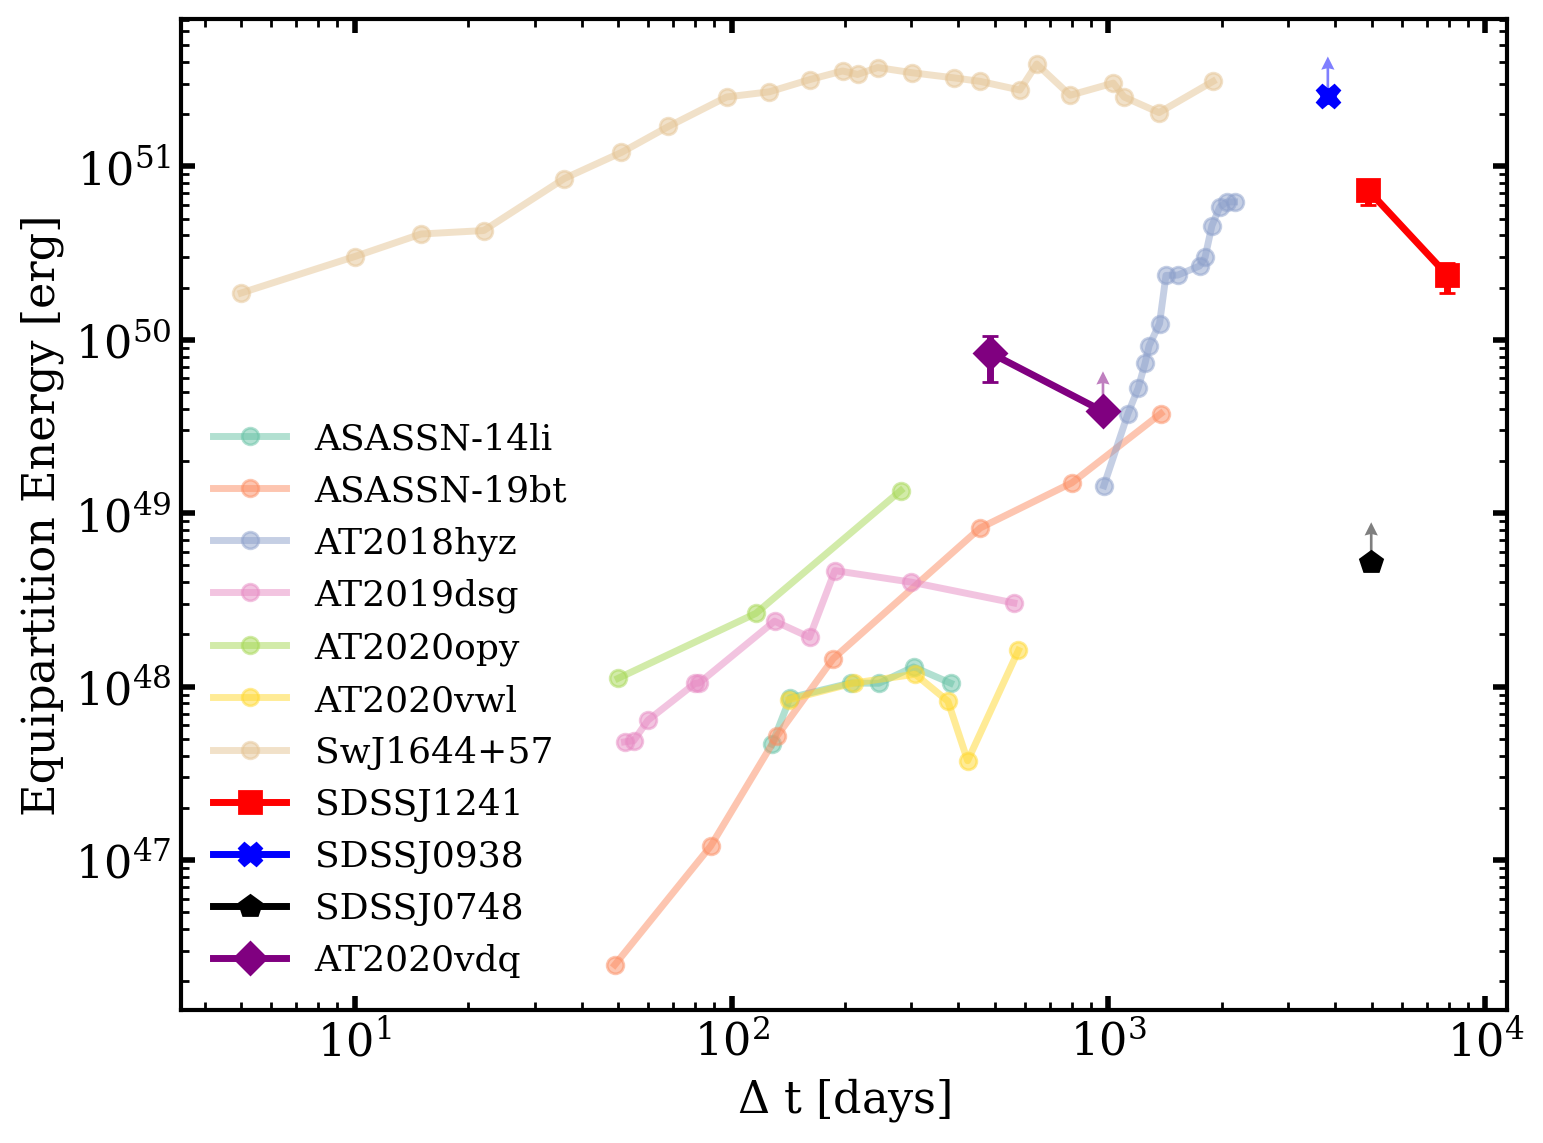

In [13]:
fig, ax = plt.subplots(figsize=(8,6))

symbs_idx = 0
label_idx = 0
color_idx = 0
names = []

xkey = "t"
        
for name, grp in lit.groupby("Name"):   
    
    grp = grp.sort_values("t")
    
    ax.errorbar(
        grp[xkey], #[label_idx],
        grp.Eeq,
        marker = "o", #symbs[symbs_idx],
        linestyle = "-",
        label = name,
        zorder = -100,
        alpha=0.5,
        # mew=0,
        color = plt.cm.Set2(color_idx)
    )
    
    # ax.axvline(label_idx-0.5, color='k', alpha=0.1)
    
    color_idx += 1
    label_idx += 1
    names.append(name)
    
# add the ECLE density profiles
for name in ["SDSS_J1241", "SDSS_J0938", "SDSS_J0748", "2020vdq"]:
    
    label_name = name.replace("_", "")
    grp = results_df[results_df.name == label_name]

    color, symb = color_dict[label_name]
    
    if label_name == "2020vdq":
        label_name = "AT"+label_name
    
    # if name not in names_to_plot: continue
    if xkey == "t":
        meta = db.get_meta(names=name, query_private=True)
        dd = meta[0].get_discovery_date().mjd
        dt = grp.mjd.values.astype(float) - dd
        print(dt)
        grp['t'] = dt
        
    yerr = [(0,0)]*len(grp)
    if len(grp[~grp.Eeq_lim]) > 0:
        yerr = [(r.Eeq_up, r.Eeq_lo) if not r.Eeq_lim else (0, 0) for _,r in grp.iterrows()]
        
    xerr = [(0,0)]*len(grp)
    if xkey != "t" and len(grp[~grp.Req_lim]) > 0:
        xerr = [(r.Req_up, r.Req_lo) if not r.Req_lim else (0, 0) for _,r in grp.iterrows()]
    
    ax.errorbar(
        grp[xkey],
        grp.Eeq,
        yerr = list(zip(*yerr)),
        xerr = list(zip(*xerr)),
        color = color,
        label = label_name,
        linestyle = "-",
        marker = symb, #symbs[symbs_idx],
        capsize = 3,
        zorder = ecle_zorder,
        ms=8
    )
    
    
    symbs_idx += 1
    
    if xkey == "Req":
        r_lim = grp[grp.Req_lim]
        if not len(r_lim): continue
        direction = "left" if r_lim.Req_lim_type.iloc[0] == "upper" else "right"
        draw_limit_arrow(r_lim, ax, direction, color=color, alpha=0.5, scale=SCALE, zorder=ecle_zorder, xkey=xkey, ykey="Eeq", norm_Req=False)
    elif xkey == "t":
        #@draw_limit_arrow(grp, ax, "right", color=color_dict[label_name], alpha=0.5, scale=SCALE, zorder=ecle_zorder, xkey=xkey, ykey="Eeq", norm_Req=False)
        pass
    else:
        raise ValueError()
    
    E_lim = grp[grp.Eeq_lim]
    if not len(E_lim): continue
    direction = "down" if E_lim.Eeq_lim_type.iloc[0] == "upper" else "up"
    draw_limit_arrow(E_lim, ax, direction, color=color, alpha=0.5, scale=SCALE, zorder=ecle_zorder, xkey=xkey, ykey="Eeq", norm_Req=False)


# PTF10tqv afterglow (Schroeder+25)
# E_err = (10**51.7 - 10**51)/2
# E_10tqv = 10**51 + E_err
# ax.errorbar(
#     [3623], 
#     [E_10tqv],
#     yerr = [E_err],
#     marker = "o",
#     capsize=3,
#     markerfacecolor = "none",
#     color = "k",
#     label = "PTF10tqv\n(SN Ic-BL)",
#     alpha = 0.4
# )
    
ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xlabel(r"$\Delta$ t [days]", fontsize=16)
ax.set_ylabel("Equipartition Energy [erg]", fontsize=16)

# ax.legend(fontsize=10, frameon=False, ncols=1, fancybox=False)
handles, labels = ax.get_legend_handles_labels()
handles = [h[0] if isinstance(h, container.ErrorbarContainer) else h for h in handles]
ax.legend(handles, labels, loc="lower left", fontsize=13, ncols=1)

fig.savefig("ecle-energy-comparison.png", bbox_inches="tight")

# calcualte the outflow velocity

In [14]:
j1241_res = results_df[results_df.name == "SDSSJ1241"]

def beta(dt, R, z):
    return ((1 + c.c*dt / (R*(1+z)))**-1).cgs

R = np.diff(j1241_res.Req) * u.cm
dt = np.diff(j1241_res.mjd.astype(float)) * u.day
beta(dt, R, db.get_meta(names="SDSS_J1241", query_private=True)[0].get_redshift())

<Quantity [0.00651751]>

# get the derived parameters table

In [15]:
results_df

,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,Req_lim,Req_lim_type,Eeq_chain,Eeq,Eeq_up,Eeq_lo,Eeq_lim,Eeq_lim_type,Req_Rs_err_lo,Req_Rs_err_up
0,SDSSJ1241,60967.0,3.344417,0.103923,0.102835,"[3.570390563530611, 3.414472542313548, 3.41673...",0.557362,0.020544,0.021181,"[0.6061386453855283, 0.5897357587586554, 0.573...",...,False,lower,"[3.8263337607225385e+50, 2.9322828660897612e+5...",2.373223e+50,5.003704e+49,4.137755e+49,False,lower,300693.755067,300778.208120
1,SDSSJ1241,57959.0,3.715698,0.111777,0.113040,"[3.784832971467307, 3.761122057160362, 3.82533...",0.927823,0.019403,0.019101,"[0.9757941369587491, 0.9538145093086272, 0.922...",...,False,lower,"[9.680402138590008e+50, 8.570335531793921e+50,...",7.262442e+50,1.285248e+50,1.114724e+50,False,lower,271821.720973,272493.004018
2,SDSSJ0938,57912.0,3.080320,0.097976,0.089055,"[3.172430747348819, 3.027818050777822, 3.14290...",0.791475,0.000000,0.000000,"[1.7989236309876087, 1.1722949367321158, 0.855...",...,True,lower,"[3.700070522381106e+53, 1.4685171114003402e+52...",2.529247e+51,0.000000e+00,0.000000e+00,True,lower,76106.032335,76106.032335
3,SDSSJ0748,57914.0,2.578675,0.322065,0.300198,"[2.7467678274288003, 2.8965330559289035, 3.508...",-0.556240,0.000000,0.000000,"[1.538386774513024, -0.4591400117233304, -0.47...",...,True,lower,"[5.081052133290154e+53, 1.1686862823988807e+49...",5.215960e+48,0.000000e+00,0.000000e+00,True,lower,87370.354779,87370.354779
4,2020vdq,59612.0,3.603838,0.168829,0.170431,"[3.783740311958792, 3.71085336133162, 3.299991...",0.571225,0.012783,0.013738,"[0.5887470398724602, 0.5840821440011682, 0.563...",...,False,lower,"[1.1241721276411515e+50, 1.0375862508541863e+5...",8.409678e+49,2.690011e+49,2.114514e+49,False,lower,NaN,NaN
5,2020vdq,60093.5,2.624550,0.033250,0.032338,"[2.713577752829935, 2.571554053874018, 2.60923...",0.305844,0.000000,0.000000,"[1.30690453912328, 0.9816892624230561, 0.47806...",...,True,lower,"[9.254301037410566e+51, 1.7665586615871678e+51...",3.870644e+49,0.000000e+00,0.000000e+00,True,lower,NaN,NaN


In [16]:
basecolnames = ["p", "log_F_nu", "log_nu_a", "n_e", "Req", "Eeq"]

dflatex_dict = {
    c:[] for c in basecolnames
}

def parse(val):
    base, power = val.split("e")
    if int(power) == 0:
        return base
    return f"{base}\\times 10^{{{int(power)}}}"

for _, row in results_df.iterrows():
    print(row["name"], row["mjd"])
    for basecolname in basecolnames:
        print(
            row[basecolname],
            row[basecolname+"_up"],
            row[basecolname+"_lo"],
            row[basecolname+"_lim"],
            row[basecolname+"_lim_type"]
        )

        if row[basecolname+"_lim"]:
            # then this should be a 3 sigma limit displayed in the table
            if row[basecolname+"_lim_type"] == "upper":
                presymb = "<"
            else:
                presymb = ">"
            dflatex_dict[basecolname].append(f"${presymb}{parse(f'{row[basecolname]:.2e}')}$")
            
        else:
            dflatex_dict[basecolname].append(f"${row[basecolname]:.2e}^{{+{row[basecolname+"_up"]:.2e}}}_{{-{row[basecolname+"_lo"]:.2e}}}$")

dflatex_dict["name"] = results_df.name
dflatex_dict["mjd"] = results_df.mjd

SDSSJ1241 60967.0
3.3444165238479 0.10392252508751243 0.10283505205221966 False upper
0.5573621944502947 0.020544237878669658 0.021180897970605295 False lower
8.84935037006478 0.02246610967739393 0.024252377520108226 False upper
14.493114625506415 3.5114761790467774 2.946469515924001 False upper
5.0217849912419776e+17 2.455923921968979e+16 2.341268015165587e+16 False lower
2.3732228574992004e+50 5.003703632666291e+49 4.1377546102578117e+49 False lower
SDSSJ1241 57959.0
3.715698080871803 0.11177711041367022 0.11304004304506732 False upper
0.927822760149608 0.01940303306164959 0.019101305657320378 False lower
9.094378819507332 0.02646010314003533 0.030968908213607094 False upper
59.8874927091085 16.513260990784815 14.14210875505421 False upper
4.531207327153999e+17 3.3728125860968256e+16 2.7238554761206464e+16 False lower
7.26244236031727e+50 1.2852481283320317e+50 1.1147242352577965e+50 False lower
SDSSJ0938 57912.0
3.08031983531389 0.09797617675947867 0.0890547724650963 False upper
0.7

In [17]:
df = pd.DataFrame(dflatex_dict)
print(df[["name", "mjd", "p", "log_F_nu", "log_nu_a", "n_e", "Req", "Eeq"]].to_latex(index=False))

\begin{tabular}{llllllll}
\toprule
name & mjd & p & log_F_nu & log_nu_a & n_e & Req & Eeq \\
\midrule
SDSSJ1241 & 60967.0 & $3.34e+00^{+1.04e-01}_{-1.03e-01}$ & $5.57e-01^{+2.05e-02}_{-2.12e-02}$ & $8.85e+00^{+2.25e-02}_{-2.43e-02}$ & $1.45e+01^{+3.51e+00}_{-2.95e+00}$ & $5.02e+17^{+2.46e+16}_{-2.34e+16}$ & $2.37e+50^{+5.00e+49}_{-4.14e+49}$ \\
SDSSJ1241 & 57959.0 & $3.72e+00^{+1.12e-01}_{-1.13e-01}$ & $9.28e-01^{+1.94e-02}_{-1.91e-02}$ & $9.09e+00^{+2.65e-02}_{-3.10e-02}$ & $5.99e+01^{+1.65e+01}_{-1.41e+01}$ & $4.53e+17^{+3.37e+16}_{-2.72e+16}$ & $7.26e+50^{+1.29e+50}_{-1.11e+50}$ \\
SDSSJ0938 & 57912.0 & $3.08e+00^{+9.80e-02}_{-8.91e-02}$ & $>7.91\times 10^{-1}$ & $<8.92$ & $<1.16\times 10^{1}$ & $>1.20\times 10^{18}$ & $>2.53\times 10^{51}$ \\
SDSSJ0748 & 57914.0 & $2.58e+00^{+3.22e-01}_{-3.00e-01}$ & $>-5.56\times 10^{-1}$ & $<9.00$ & $<2.08\times 10^{1}$ & $>1.40\times 10^{17}$ & $>5.22\times 10^{48}$ \\
2020vdq & 59612.0 & $3.60e+00^{+1.69e-01}_{-1.70e-01}$ & $5.71e-01^{+1.28e-02